# KIND model training

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '253',
        '--data_nsample_exc', '460',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--back_nsample', '64',
        '--fore_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/dreamer',

        '--rez_nsample_nom', '32',
        '--rez_nsample_exc', '16',
        '--embed_nom', '{"sin": 6, "cos": 6}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.back_nsample, args.fore_nsample), setpoint, load_normalized=True)

training = kind.training(model)

## Train nominal model

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=1.190205, valid=1.194309, test=1.242619
	validation loss decreased (inf -> 1.194309), saving model ...
	epoch 2 losses: train=1.115722, valid=1.164357, test=1.208619
	validation loss decreased (1.194309 -> 1.164357), saving model ...
	epoch 3 losses: train=1.120925, valid=1.127396, test=1.167109
	validation loss decreased (1.164357 -> 1.127396), saving model ...
	epoch 4 losses: train=1.046685, valid=1.077369, test=1.111000
	validation loss decreased (1.127396 -> 1.077369), saving model ...
	epoch 5 losses: train=0.952495, valid=1.013289, test=1.037812
	validation loss decreased (1.077369 -> 1.013289), saving model ...
	epoch 6 losses: train=0.950650, valid=0.948296, test=0.958164
	validation loss decreased (1.013289 -> 0.948296), saving model ...
	epoch 7 losses: train=0.840361, valid=0.903829, test=0.908298
	validation loss decreased (0.948296 -> 0.903829), saving model ...
	epoch 8 losses: train=0.810827, valid=0.866088, test=0.87

In [5]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

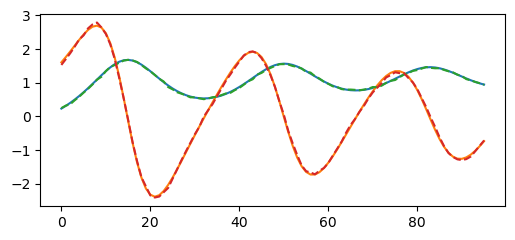

In [6]:
jdata = 15

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break


## Train nominal model's uncertainty

In [7]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=1.068823, valid=0.799151, test=2.515350
	validation loss decreased (inf -> 0.799151), saving model ...
	epoch 2 losses: train=1.067083, valid=0.768969, test=2.432800
	validation loss decreased (0.799151 -> 0.768969), saving model ...
	epoch 3 losses: train=0.974135, valid=0.742889, test=2.318774
	validation loss decreased (0.768969 -> 0.742889), saving model ...
	epoch 4 losses: train=1.041782, valid=0.699565, test=2.126692
	validation loss decreased (0.742889 -> 0.699565), saving model ...
	epoch 5 losses: train=0.896039, valid=0.644820, test=1.892108
	validation loss decreased (0.699565 -> 0.644820), saving model ...
	epoch 6 losses: train=0.845920, valid=0.568491, test=1.847773
	validation loss decreased (0.644820 -> 0.568491), saving model ...
	epoch 7 losses: train=0.742068, valid=0.536937, test=1.635249
	validation loss decreased (0.568491 -> 0.536937), saving model ...
	epoch 8 losses: train=0.737247, valid=0.502443, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

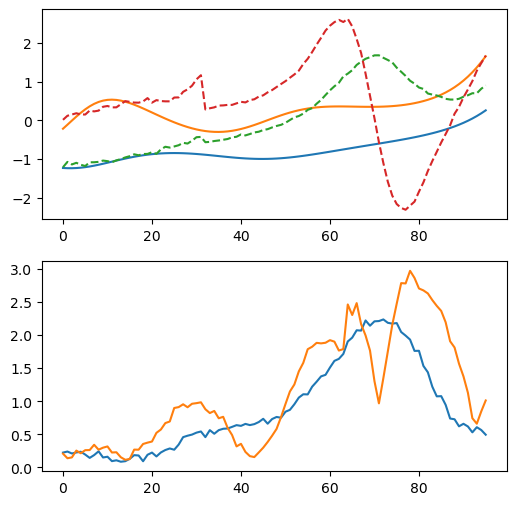

In [9]:
jdata = 5

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :2])

        plt.show()

        break


## Train excursion model

In [10]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.903035, valid=0.867940, test=0.961755
	validation loss decreased (inf -> 0.867940), saving model ...
	epoch 2 losses: train=0.883169, valid=0.832571, test=0.932046
	validation loss decreased (0.867940 -> 0.832571), saving model ...
	epoch 3 losses: train=0.840520, valid=0.786184, test=0.894820
	validation loss decreased (0.832571 -> 0.786184), saving model ...
	epoch 4 losses: train=0.815246, valid=0.693636, test=0.804447
	validation loss decreased (0.786184 -> 0.693636), saving model ...
	epoch 5 losses: train=0.693385, valid=0.565309, test=0.690761
	validation loss decreased (0.693636 -> 0.565309), saving model ...
	epoch 6 losses: train=0.647499, valid=0.520253, test=0.656687
	validation loss decreased (0.565309 -> 0.520253), saving model ...
	epoch 7 losses: train=0.608714, valid=0.510795, test=0.632240
	validation loss decreased (0.520253 -> 0.510795), saving model ...
	epoch 8 losses: train=0.518527, valid=0.446041, test=0.

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

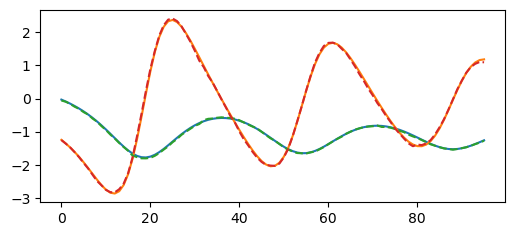

In [12]:
jdata = 7

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

## Train excursion model's uncertainty

In [13]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.258124, valid=0.257427, test=0.252466
	validation loss decreased (inf -> 0.257427), saving model ...
	epoch 2 losses: train=0.250462, valid=0.251255, test=0.244497
	validation loss decreased (0.257427 -> 0.251255), saving model ...
	epoch 3 losses: train=0.234768, valid=0.249011, test=0.240214
	validation loss decreased (0.251255 -> 0.249011), saving model ...
	epoch 4 losses: train=0.220494, valid=0.247919, test=0.238935
	validation loss decreased (0.249011 -> 0.247919), saving model ...
	epoch 5 losses: train=0.239509, valid=0.247547, test=0.239106
	validation loss decreased (0.247919 -> 0.247547), saving model ...
	epoch 6 losses: train=0.239453, valid=0.247476, test=0.239200
	validation loss decreased (0.247547 -> 0.247476), saving model ...
	epoch 7 losses: train=0.231263, valid=0.247339, test=0.239278
	validation loss decreased (0.247476 -> 0.247339), saving model ...
	epoch 8 losses: train=0.237248, valid=0.247361, 

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

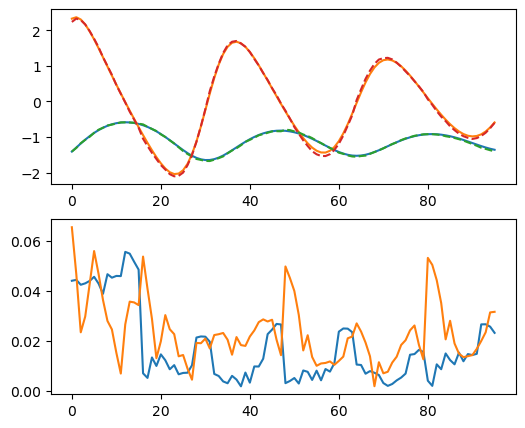

In [15]:
jdata = 5

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

## Evaluate KIND blending

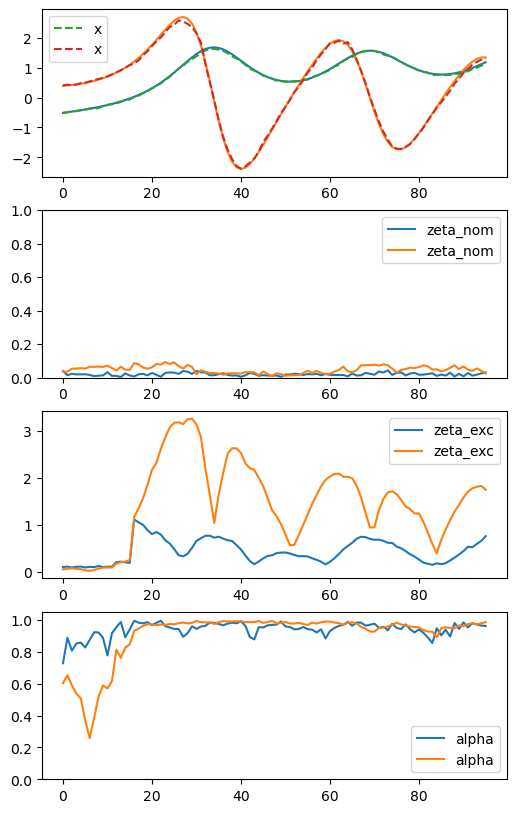

In [17]:
jdata = 4

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break